# Question 2 - Specific Deprivation Factors
### Research question: Among the different sub-domains of deprivation, which specific factor (if any) has the strongest negative correlation with a region's educational outcomes?

##### Sub-domains of deprivation
1. Income
2. Employment
3. Health
4. Crime
5. Living environment
6. Barriers to housing

This reasearch question explores how the different sub-domains of deprivation might impact educational outcomes. Gaining an understanding of which aspects of deprivation are more strongly correlated with educational outcomes is important for stakeholders looking to identify/prioritise areas of improvement. This is particularly important in areas of high deprivation across the board where stakeholders are looking to improve and higher local educational attainment.

To answer research question two, two main aspects were investigated:
1. Overall correlation between each deprivation factor and the attainment 8 average scores across all local authorities. This provides an overview of which deprivation factors are more strongly associated with educational outcomes at a national level.
2. Correlation between each deprivation factor and the attainment 8 average scores across all local authorities by year. This provides information on whether the relationships between deprivation factor and attainment 8 average remain similar over time or whether strengths of correlation change a lot depending on the year.

Within-area correlation analysis was not possible because deprivation factors and attainment8 average scores are single values per local authority, resulting in no within-area variation.



In [ ]:
# Import relevant python libraries for this analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [234]:
# Code to load and clean data to remove the columns not relevant to the analysis for this question
df = pd.read_csv("data/total_geo_agg.csv")

df_clean = df[["time_period",
               "attainment8_average", 
               "income_score", 
               "employment_score", 
               "health_score", 
               "crime_score", 
               "barriers_score", 
               "living_env_score", 
               "idaci_score"
               ]]

# Shows cleaned data, columns and top 5 rows
df_clean.head()

,time_period,attainment8_average,income_score,employment_score,health_score,crime_score,barriers_score,living_env_score,idaci_score
0,201819,43.0,0.228315,0.182650,0.868537,0.566198,14.241918,6.943125,0.266986
1,201819,41.5,0.251208,0.188890,1.193741,0.700957,14.183107,12.928813,0.300013
2,201819,43.8,0.186187,0.162705,0.789854,0.137734,14.138944,7.793080,0.233006
3,201819,46.4,0.163999,0.134090,0.684090,-0.111080,15.869762,6.007198,0.196141
4,201819,46.6,0.153240,0.125782,0.531791,0.558393,11.942232,8.800320,0.190718


In [120]:
# Quick check for any null entries incase they were missed in initial project data cleaning
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 1043 entries, 0 to 1042
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   time_period          1043 non-null   int64  
 1   attainment8_average  1043 non-null   float64
 2   income_score         1043 non-null   float64
 3   employment_score     1043 non-null   float64
 4   health_score         1043 non-null   float64
 5   crime_score          1043 non-null   float64
 6   barriers_score       1043 non-null   float64
 7   living_env_score     1043 non-null   float64
 8   idaci_score          1043 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 73.5 KB


In [145]:
# Code to calulate correlations for each deprivation factor to attainment8_average
correlations = df_clean.corr(numeric_only=True)["attainment8_average"]
correlations = correlations.drop("attainment8_average")
correlations = correlations.drop("time_period")

# To display correlations in a table
correlation_table = (
    correlations
    .sort_values()
    .to_frame(name="Correlation_with_a8_avg")
)

correlation_table

,Correlation_with_a8_avg
health_score,-0.622177
employment_score,-0.582942
idaci_score,-0.494178
income_score,-0.489342
crime_score,-0.274403
living_env_score,-0.000268
barriers_score,0.350325


In [124]:
# Code to print which deprivation factor had the highest correlation overall with attainment8_average
strongest = correlations.abs().idxmax()
value = correlations[strongest]

print("Strongest correlation with attainment8_average:")
print(strongest, value)

Strongest correlation with attainment8_average:
health_score -0.6221771680888855


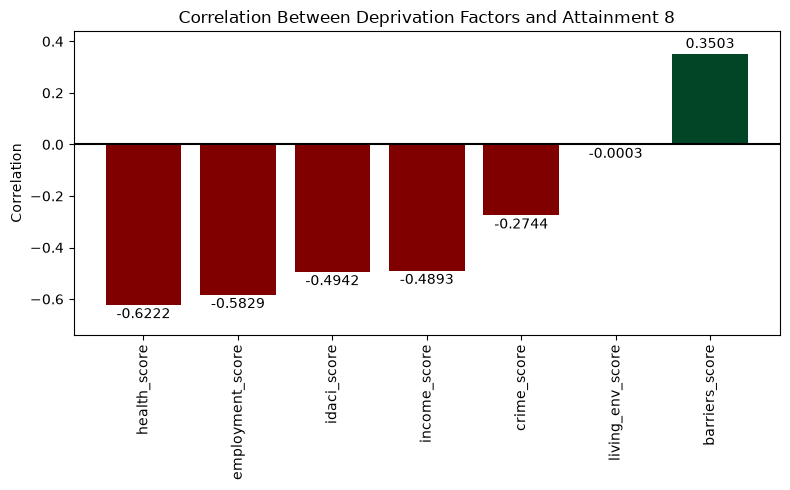

In [179]:
# Code to generate a bar chart that shows the overall correlation between each deprivation factor and attainment8_average.
correlations = correlations.sort_values()

plt.figure(figsize=(8, 5))

colours = ["#800000" if value < 0 else "#004526" for value in correlations.values]
bars = plt.bar(correlations.index, correlations.values, color=colours)

# To add value labels on top of bars and add space on y axis so the labels aren't obstructed
plt.bar_label(bars, fmt='%.4f', padding=2)

ymin, ymax = plt.ylim()
plt.ylim(ymin * 1.1, ymax * 1.1)

# Add a line at 0 for better visualisation
plt.axhline(0, color='black')

plt.ylabel('Correlation')
plt.title('Correlation Between Deprivation Factors and Attainment 8')

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [235]:
# Code to calculate the correlation in each year for each deprivation factor to attainment8_average
# This is done to investigate whether different years showed different deprivation factors with the strongest correlation to attainment8_average 
# Also useful for investigating if COVID years had an impact on which deprivation factor influenced education the most
deprivation_factors = [
    "income_score",
    "employment_score",
    "health_score",
    "crime_score",
    "barriers_score",
    "living_env_score",
    "idaci_score"
]

year_correlation = (
    df_clean
    .groupby("time_period")[deprivation_factors + ["attainment8_average"]]
    .corr()["attainment8_average"]
    .unstack()
)

year_correlation

,income_score,employment_score,health_score,crime_score,barriers_score,living_env_score,idaci_score,attainment8_average
time_period,,,,,,,,
201819,-0.584135,-0.657042,-0.695536,-0.361579,0.327726,-0.037167,-0.600591,1.0
201920,-0.597752,-0.672967,-0.719311,-0.375468,0.355204,-0.022217,-0.609541,1.0
202021,-0.587710,-0.670372,-0.717739,-0.368080,0.355963,-0.030553,-0.593993,1.0
202122,-0.558686,-0.664891,-0.697510,-0.323540,0.390203,-0.017467,-0.558207,1.0
202223,-0.507766,-0.626992,-0.676962,-0.258921,0.410069,-0.005691,-0.510705,1.0
202324,-0.501434,-0.636252,-0.681687,-0.235240,0.444379,0.052575,-0.501192,1.0
202425,-0.481088,-0.605621,-0.649854,-0.234563,0.418767,0.045061,-0.484147,1.0


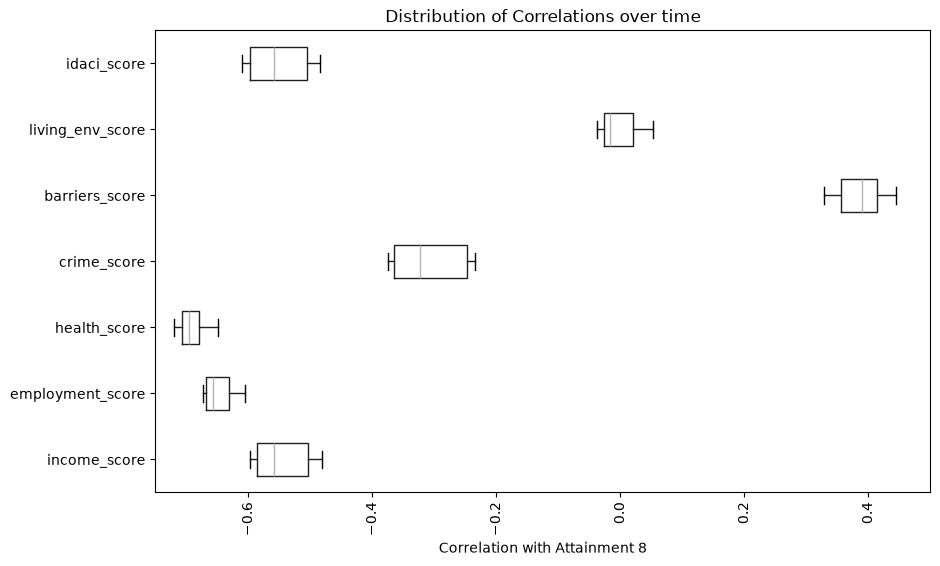

In [236]:
# Boxplots to visualise the distribution of correlations over time
deprivation_columns = [
    "income_score",
    "employment_score",
    "health_score",
    "crime_score",
    "barriers_score",
    "living_env_score",
    "idaci_score"
]

plt.figure(figsize=(10,6))

year_correlation.boxplot(column=deprivation_columns, grid=False, vert=False)

plt.xticks(rotation=90)
plt.xlabel("Correlation with Attainment 8")
plt.title("Distribution of Correlations over time")

plt.xlim(-0.75, 0.5)

plt.show()

In [240]:
# Code to check which deprivation factor had the strongest negative correlation with attainment8_average each year
strongest_df = pd.DataFrame({
    "Year": year_correlation.index,
    "Strongest Factor": year_correlation.idxmin(axis=1),
    "Correlation": year_correlation.min(axis=1)
})

strongest_df

,Year,Strongest Factor,Correlation
time_period,,,
201819,201819,health_score,-0.695536
201920,201920,health_score,-0.719311
202021,202021,health_score,-0.717739
202122,202122,health_score,-0.697510
202223,202223,health_score,-0.676962
202324,202324,health_score,-0.681687
202425,202425,health_score,-0.649854


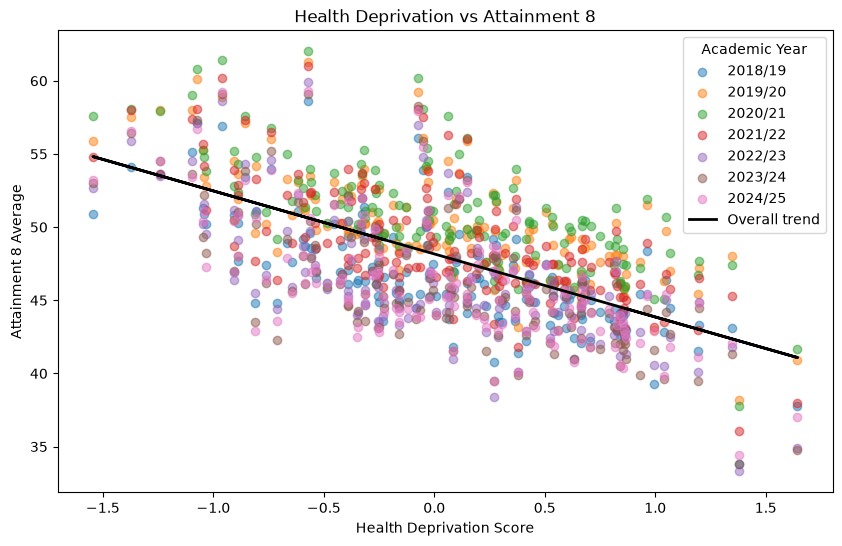

In [ ]:
# Code to make sscatter graph for showing health_score against attainment8 average
plt.figure(figsize=(10,6))

for year in df_clean["time_period"].unique():
    subset = df_clean[df_clean["time_period"] == year]
    
    plt.scatter(
        subset["health_score"],
        subset["attainment8_average"],
        alpha=0.5
    )

# To create lline of best fit/regression line
x = df_clean["health_score"]
y = df_clean["attainment8_average"]

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color="black", linewidth=2, label="Overall trend")

plt.xlabel("Health Deprivation Score")
plt.ylabel("Attainment 8 Average")
plt.title("Health Deprivation vs Attainment 8")

plt.legend(title="Academic Year", labels=[
    "2018/19",
    "2019/20",
    "2020/21",
    "2021/22",
    "2022/23",
    "2023/24",
    "2024/25",
    "Overall trend"
])

plt.show()


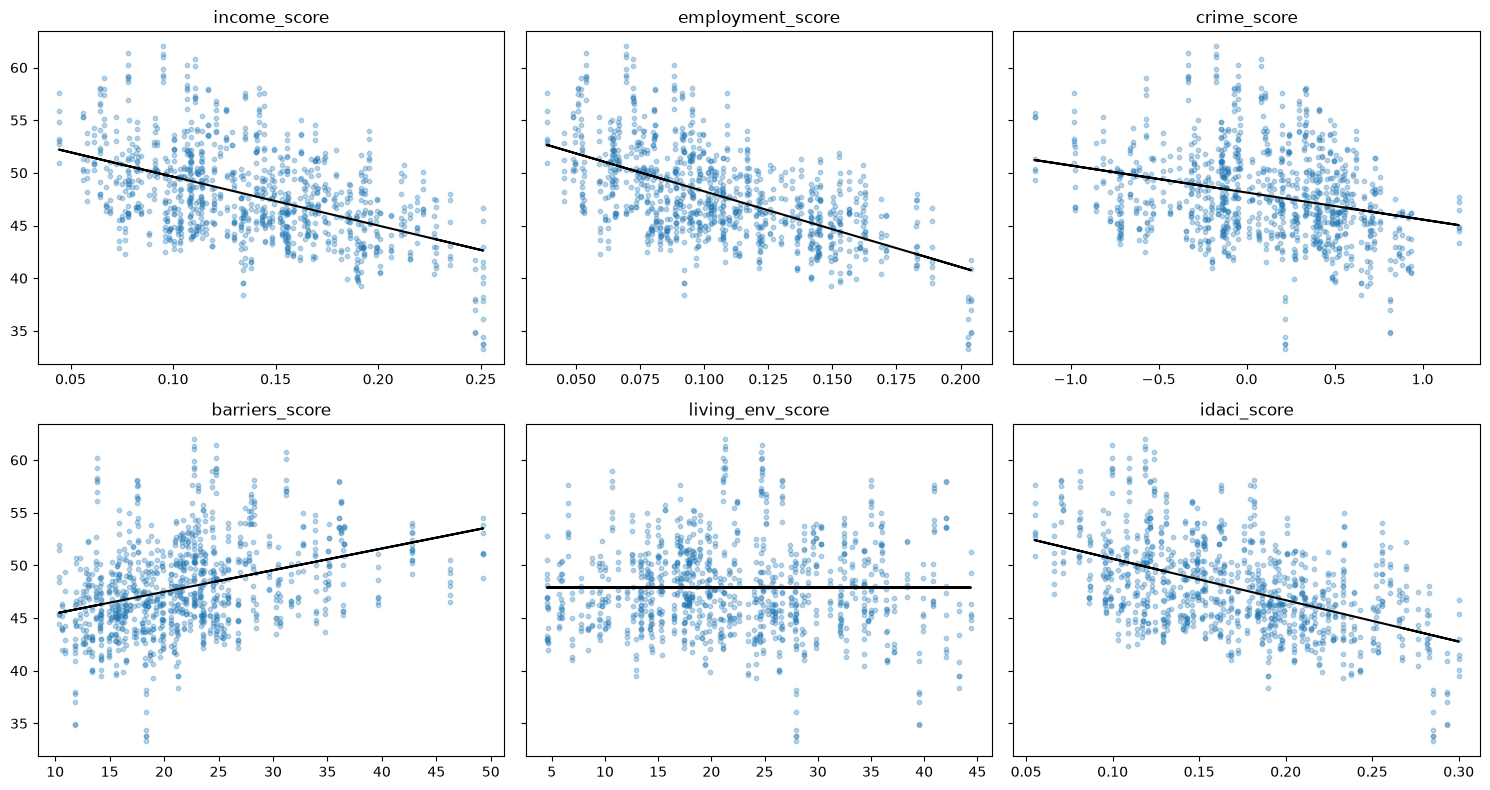

In [ ]:
# Smaller scatter plots for visualisation of the regression lines for each deprivation factor
# Coulld be useful for visual comparison for sttakeholders etc
factors = [
    "income_score",
    "employment_score",
    "crime_score",
    "barriers_score",
    "living_env_score",
    "idaci_score"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
axes = axes.flatten()

for i, factor in enumerate(factors):

    axes[i].scatter(
        df_clean[factor],
        df_clean["attainment8_average"],
        alpha=0.3,
        s=10
    )

    m, b = np.polyfit(df_clean[factor], df_clean["attainment8_average"], 1)
    axes[i].plot(df_clean[factor], m*df_clean[factor] + b, color="black")

    axes[i].set_title(factor)

plt.tight_layout()
plt.show()

### Conclusions for Q2

This analysis has found that in general higher levels of deprivation lead to worse attainment 8 averages, with the exception of barrier_score that exhibited positive correlation.

Barrier_score is a measure that represents deprivation in access to housing and social services. More research should be done into why this analysis found a positive correlation between barrier_score and attainment8_average as current literature suggests a negative correlation is to be expected.

Of the remaining correlations, health_score exhibited the highest negative correlation when both examining the data overall and on a year-by-year basis. This strongly suggests that higher deprivation levels on health related issues may influence lower attainment8_averages. 